# 📊 Google Play Store Apps — Complete EDA & Data Cleaning


## 📚 Table of Contents

1. **Importing Libraries** — Set up our data analysis environment
2. **Data Loading & Exploration** — Understand the raw data structure
3. **Data Cleaning & Wrangling** — Fix messy columns and missing values
4. **Feature Engineering** — Create useful new features
5. **Exploratory Analysis** — Answer key business questions
6. **Summary & Insights** — Takeaways for app developers

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# 3. Suppress warnings to keep the output clean
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2️⃣ Data Loading & Exploration

Let's load our dataset and get familiar with its structure.

In [2]:
df = pd.read_csv('/kaggle/input/datasets/lava18/google-play-store-apps/googleplaystore.csv')

### 📋 First Look at the Data

In [3]:
df.head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


> **Note**: Some the output of notebook does not present the complete output, therefore we can increase the limit of columns view and row view by using these commands: 

In [4]:
pd.set_option('display.max_columns', None) # Display all the columns in the dataframe
pd.set_option('display.max_rows', None) # Display all the rows in the dataframe

### 📌 Column Names

In [5]:
print(f"Columns in dataset are {df.columns}")

Columns in dataset are Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')


### 📏 Dataset Dimensions

In [6]:
print(f"Rows are {df.shape[0]} and columns are {df.shape[1]}.")

Rows are 10841 and columns are 13.


### 🔍 Data Types & Info

- When i check it from csv preview
- I found that the single row values shifted from left to right
- So first solve this

In [7]:
df.loc[df['App'] == 'Life Made WI-Fi Touchscreen Photo Frame'] = \
df.loc[df['App'] == 'Life Made WI-Fi Touchscreen Photo Frame'].shift(1, axis=1)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   App             10840 non-null  object
 1   Category        10841 non-null  object
 2   Rating          9367 non-null   object
 3   Reviews         10841 non-null  object
 4   Size            10841 non-null  object
 5   Installs        10841 non-null  object
 6   Type            10840 non-null  object
 7   Price           10841 non-null  object
 8   Content Rating  10841 non-null  object
 9   Genres          10840 non-null  object
 10  Last Updated    10841 non-null  object
 11  Current Ver     10833 non-null  object
 12  Android Ver     10839 non-null  object
dtypes: object(13)
memory usage: 1.1+ MB


### 💡 Key Observations

**Dataset Summary:**
- **Rows:** 10,841 apps | **Columns:** 13 features
- **Data Types:** Mix of categorical and numeric

**Columns:**
`App`, `Category`, `Rating`, `Reviews`, `Size`, `Installs`, `Type`, `Price`, `Content Rating`, `Genres`, `Last Updated`, `Current Ver`, `Android Ver`

**Data Quality Issues Identified:**
- ⚠️ Missing values in `Rating`, `Current Ver`, `Android Ver` (will handle later)

- ⚠️ Columns that look numeric but are stored as text: `Size` (has K/M), `Installs` (has +), `Price` (has $)**Next Step:** Clean and convert these columns to proper numeric types.

- ⚠️ Possible duplicates (will investigate)

In [9]:
df.describe()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10840,10841,9367.0,10841,10841,10841,10840,10841,10841,10840,10841,10833,10839
unique,9659,34,40.0,6002,461,21,2,92,6,119,1377,2831,33
top,ROBLOX,FAMILY,4.4,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,1109.0,596,1695,1579,10040,10041,8715,842,326,1459,2451


---

## 3️⃣ Data Cleaning & Wrangling

Now let's fix the messy columns and prepare our data for analysis.

### 🧹 Cleaning Step 1: The `Size` Column

**Solution:** Convert all to a common unit (MB) and handle special cases.
**Problem:** Size is stored as text with K (kilobytes) and M (megabytes) units.  

In [10]:
# check null values
df['Size'].isnull().sum()

np.int64(0)

- No null values, we are good to go.

In [11]:
# check unique values
df['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

-  There are several uniques values in the `Size` column, we have to first make the unit into one common unit from M and K to bytes, and then remove the `M` and `K` from the values and convert them into numeric data type.

In [12]:
df.Size.value_counts().sum()

np.int64(10841)

In [13]:
# values having M in size column
df[df['Size'].str.contains('M', na=False)]['Size'].value_counts().sum()

np.int64(8830)

In [14]:
# values having K in size column
df['Size'].loc[df['Size'].str.contains('k')].value_counts().sum()

np.int64(316)

In [15]:
# values having varies with device in size column
df['Size'].loc[df['Size'].str.contains('Varies with device')].value_counts().sum()

np.int64(1695)

In [16]:
# Total Values in Size column
df['Size'].value_counts().sum()

np.int64(10841)

- We have `8830` values in `M` units
- We have `316` values in `k` units
- We have `1695` value in `Varies with device` 

> Let's convert the `M` and `K` units into bytes and then remove the `M` and `K` from the values and convert them into numeric data type.

In [17]:
# add function to convert size column into numeric values
def convert_size(size):
    if 'k' in size:
        return float(size.replace('k', '')) / 1024
    elif 'M' in size:
        return float(size.replace('M', ''))
    elif 'Varies with device' in size:
        return np.nan
    return size

In [18]:
# apply the function to the size column
df['Size'] = df['Size'].apply(convert_size)

In [19]:
# rename the column name 'Size' to 'Size_in_mb'
df.rename(columns={'Size': 'Size_in_mb'}, inplace=True)

In [20]:
# now check the size column
df['Size_in_mb'].tail(20)

10821     2.500000
10822     3.100000
10823     2.900000
10824    82.000000
10825     7.700000
10826          NaN
10827    13.000000
10828    13.000000
10829     7.400000
10830     2.300000
10831     9.800000
10832     0.568359
10833     0.604492
10834     2.600000
10835     9.600000
10836    53.000000
10837     3.600000
10838     9.500000
10839          NaN
10840    19.000000
Name: Size_in_mb, dtype: float64

In [21]:
# check remaining null values
df["Size_in_mb"].isnull().sum()

np.int64(1695)

In [22]:
# check unique values for confirmation
df["Size_in_mb"].unique()

array([1.90000000e+01, 1.40000000e+01, 8.70000000e+00, 2.50000000e+01,
       2.80000000e+00, 5.60000000e+00, 2.90000000e+01, 3.30000000e+01,
       3.10000000e+00, 2.80000000e+01, 1.20000000e+01, 2.00000000e+01,
       2.10000000e+01, 3.70000000e+01, 2.70000000e+00, 5.50000000e+00,
       1.70000000e+01, 3.90000000e+01, 3.10000000e+01, 4.20000000e+00,
       7.00000000e+00, 2.30000000e+01, 6.00000000e+00, 6.10000000e+00,
       4.60000000e+00, 9.20000000e+00, 5.20000000e+00, 1.10000000e+01,
       2.40000000e+01,            nan, 9.40000000e+00, 1.50000000e+01,
       1.00000000e+01, 1.20000000e+00, 2.60000000e+01, 8.00000000e+00,
       7.90000000e+00, 5.60000000e+01, 5.70000000e+01, 3.50000000e+01,
       5.40000000e+01, 1.96289062e-01, 3.60000000e+00, 5.70000000e+00,
       8.60000000e+00, 2.40000000e+00, 2.70000000e+01, 2.50000000e+00,
       1.60000000e+01, 3.40000000e+00, 8.90000000e+00, 3.90000000e+00,
       2.90000000e+00, 3.80000000e+01, 3.20000000e+01, 5.40000000e+00,
      

- here we have null values of 'varies with device'

- now, using groupby function for fill null values

In [23]:
# Handling Missing Values in Size Column (Category-wise Median Imputation)
df["Size_in_mb"] = df.groupby("Category")["Size_in_mb"].transform(lambda x: x.fillna(x.median()))

In [24]:
# check null values after imputation
df.Size_in_mb.isnull().sum()

np.int64(0)

- here we have a single missing value

- use groupby function again to fill it 

In [25]:
# check which have a null value
df[df["Size_in_mb"].isna()]

,App,Category,Rating,Reviews,Size_in_mb,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [26]:
# The remaining NaN likely belongs to a Category with all NaN sizes,
# so the groupby median returns NaN again. Let's fill it with the overall median.
overall_median = df["Size_in_mb"].median()
df["Size_in_mb"] = df["Size_in_mb"].fillna(overall_median)

In [27]:
# fill the remaining NaN with the overall median (category median is NaN for this row)
df["Size_in_mb"] = df["Size_in_mb"].fillna(df["Size_in_mb"].median())

In [28]:
# check null values after final imputation
df["Size_in_mb"].isnull().sum()

np.int64(0)

- now you see have zero null value in Size_in_mb column

---
## Let's have a look on the `Installs` column

In [29]:
# check the unique values in size column
df['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0'], dtype=object)

In [30]:
df["Installs"].isnull().sum()

np.int64(0)

- there is no null values
- so go for customize it

In [31]:
# let's have a values counts
df['Installs'].value_counts()

Installs
1,000,000+        1579
10,000,000+       1252
100,000+          1169
10,000+           1054
1,000+             908
5,000,000+         752
100+               719
500,000+           539
50,000+            479
5,000+             477
100,000,000+       409
10+                386
500+               330
50,000,000+        289
50+                205
5+                  82
500,000,000+        72
1+                  67
1,000,000,000+      58
0+                  14
0                    1
Name: count, dtype: int64

In [32]:
# find how many values has '+' in it
df['Installs'].loc[df['Installs'].str.contains('\+')].value_counts().sum()

np.int64(10840)

In [33]:
# Total values in Installs column
df['Installs'].value_counts().sum()

np.int64(10841)

- The only problem I see here is the `+` sign in the values, let's remove them and convert the column into numeric data type.

- The total values in the `Installs` column are `10841` and there are no null values in the column.
- However, one value 0 has no plus sign

- Let's remove the plus sign `+` and `,` from the values and convert them into numeric data type

In [34]:
# remove the plus sign from install column and convert it to numeric
df['Installs'] = df['Installs'].apply(lambda x: x.replace('+', '') if '+' in str(x) else x)
# also remove the commas from the install column
df['Installs'] = df['Installs'].apply(lambda x: x.replace(',', '') if ',' in str(x) else x)
# convert the install column to numeric (integers because this is the number of installs/count)
df['Installs'] = df['Installs'].apply(lambda x: int(x))

- Let's verify if the dtypes has been changes and the `+` and `,` sign has been removed

In [35]:
df.head() # check the head of the dataframe

,App,Category,Rating,Reviews,Size_in_mb,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [36]:
df['Installs'].dtype # this will show the data type of the column

dtype('int64')

- We can generate a new columns based on the installation values, which will be helpful in our analysis

In [37]:
df['Installs'].max() # this will show the value counts of the column

1000000000

In [38]:
# making a new column called 'Installs_category' which will have the category of the installs
bins = [-1, 0, 10, 1000, 10000, 100000, 1000000, 10000000, 10000000000]
labels=['no', 'Very low', 'Low', 'Moderate', 'More than moderate', 'High', 'Very High', 'Top Notch']
df['Installs_category'] = pd.cut(df['Installs'], bins=bins, labels=labels)

In [39]:
df['Installs_category'].value_counts() # check the value counts of the new column

Installs_category
Low                   2162
High                  2118
Very High             2004
More than moderate    1648
Moderate              1531
Top Notch              828
Very low               535
no                      15
Name: count, dtype: int64

In [40]:
# check columns we added and customizeee
df.head()

,App,Category,Rating,Reviews,Size_in_mb,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_category
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,Moderate
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,High
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,Very High
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,Top Notch
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,More than moderate


# Let's have a look on the `Price` column

In [41]:
# check the unique values in the 'Price' column
df['Price'].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', '$1.20', '$1.04'], dtype=object)

In [42]:
df['Price'].isnull().sum()

np.int64(0)

- No Null Values

In [43]:
df['Price'].value_counts() # check the value counts of the 'Price' column

Price
0          10041
$0.99        148
$2.99        129
$1.99         73
$4.99         72
$3.99         63
$1.49         46
$5.99         30
$2.49         26
$9.99         21
$6.99         13
$399.99       12
$14.99        11
$4.49          9
$29.99         7
$3.49          7
$7.99          7
$24.99         7
$5.49          6
$19.99         6
$6.49          5
$8.99          5
$12.99         5
$11.99         5
$10.00         3
$1.00          3
$16.99         3
$2.00          3
$17.99         2
$10.99         2
$9.00          2
$79.99         2
$7.49          2
$3.95          2
$33.99         2
$1.70          2
$13.99         2
$8.49          2
$39.99         2
$1.50          1
$25.99         1
$74.99         1
$15.99         1
$3.88          1
$1.76          1
$3.02          1
$400.00        1
$4.84          1
$2.50          1
$1.59          1
$1.61          1
$4.77          1
$5.00          1
$1.29          1
$379.99        1
$299.99        1
$37.99         1
$18.99         1
$389.99 

- We need to confirm if the values in the `Price` column are only with $ sign or not

In [44]:
# count the values having $ in the 'Price' column
df['Price'].loc[df['Price'].str.contains('\$')].value_counts().sum()

np.int64(800)

In [45]:
# This code counts the number of values in the 'Price' column which contains 0 but does not contain $ sign
df['Price'].loc[(df['Price'].str.contains('0')) & (~df['Price'].str.contains('\$'))].value_counts().sum()


np.int64(10041)

- Now we can confirm that the only currency used is `$` in the `Price` column or 0 value, as `800+10041=10841 Total values`
- The only problem is $ sign let's remove it and convert the column into numeric data type.

In [46]:
# remove the dollar sign from the price column and convert it to numeric
df['Price'] = df['Price'].apply(lambda x: x.replace('$', '') if '$' in str(x) else x)
# convert the price column to numeric (float because this is the price)
df['Price'] = df['Price'].apply(lambda x: float(x))

In [47]:
df['Price'].dtype # this will show the data type of the column

dtype('float64')

In [48]:
# check price column
df["Price"].value_counts()

Price
0.00      10041
0.99        148
2.99        129
1.99         73
4.99         72
3.99         63
1.49         46
5.99         30
2.49         26
9.99         21
6.99         13
399.99       12
14.99        11
4.49          9
29.99         7
3.49          7
7.99          7
24.99         7
5.49          6
19.99         6
6.49          5
8.99          5
12.99         5
11.99         5
10.00         3
1.00          3
16.99         3
2.00          3
17.99         2
10.99         2
9.00          2
79.99         2
7.49          2
3.95          2
33.99         2
1.70          2
13.99         2
8.49          2
39.99         2
1.50          1
25.99         1
74.99         1
15.99         1
3.88          1
1.76          1
3.02          1
400.00        1
4.84          1
2.50          1
1.59          1
1.61          1
4.77          1
5.00          1
1.29          1
379.99        1
299.99        1
37.99         1
18.99         1
389.99        1
19.90         1
1.75          1
14.00         1
4.

- here we removed dollar sign

In [49]:
# using f string to print the min, max and average price of the apps
print(f"Min price is: {df['Price'].min()} $")
print(f"Max price is: {df['Price'].max()} $")
print(f"Average price is: {df['Price'].mean()} $")

Min price is: 0.0 $
Max price is: 400.0 $
Average price is: 1.0272733142699015 $


In [50]:
# check description of numeric data
df.describe()

,Size_in_mb,Installs,Price
count,10841.000000,1.084100e+04,10841.000000
mean,20.321034,1.546291e+07,1.027273
std,21.231352,8.502557e+07,15.948971
min,0.008301,0.000000e+00,0.000000
25%,5.600000,1.000000e+03,0.000000
50%,12.000000,1.000000e+05,0.000000
75%,27.000000,5.000000e+06,0.000000
max,100.000000,1.000000e+09,400.000000


## Observations:
---
- Now, we have only 5 columns as numeric data type.
- We can observe their descriptive statistics. and make tons of observations as per our hypotheses.
- We can see that the `Rating` column has a minimum value of `1` and a maximum value of `5`, which is the range of rating, and the mean is `4.19` which is a good rating. On an average people give this rating.
- We can see that the `Reviews` column has a minimum value of `0` and a maximum value of `78,158,306` 78+ Millions, which is the range of reviews, and the mean is `444,111.93` which is a good number of reviews. On an average people give this number of reviews to the apps. But it does not make sense to us, as we have different categories of apps.
- Similarly, we can observe the other columns as well.

Therefore, the most important thing is to classify as app based on the correlation matrix and then observe the descriptive statistics of the app category and number of installs, reviews, ratings, etc.

But even before that we have to think about the missing values in the dataset.
---

- Let's have a look on the missing values in the dataset

In [51]:
df.isnull().sum() # this will show the number of null values in each column

App                     1
Category                0
Rating               1474
Reviews                 0
Size_in_mb              0
Installs                0
Type                    1
Price                   0
Content Rating          0
Genres                  1
Last Updated            0
Current Ver             8
Android Ver             2
Installs_category       0
dtype: int64

In [52]:
df.isnull().sum().sort_values(ascending=False) # this will show the number of null values in each column in descending order

Rating               1474
Current Ver             8
Android Ver             2
Type                    1
Genres                  1
App                     1
Installs                0
Size_in_mb              0
Reviews                 0
Category                0
Content Rating          0
Price                   0
Last Updated            0
Installs_category       0
dtype: int64

In [53]:
df.isnull().sum().sum() # this will show the total number of null values in the dataframe

np.int64(1487)

In [54]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False) # this will show the percentage of null values in each column

Rating               13.596532
Current Ver           0.073794
Android Ver           0.018448
Type                  0.009224
Genres                0.009224
App                   0.009224
Installs              0.000000
Size_in_mb            0.000000
Reviews               0.000000
Category              0.000000
Content Rating        0.000000
Price                 0.000000
Last Updated          0.000000
Installs_category     0.000000
dtype: float64

- Let's plot the missing values in the dataset

<Axes: >

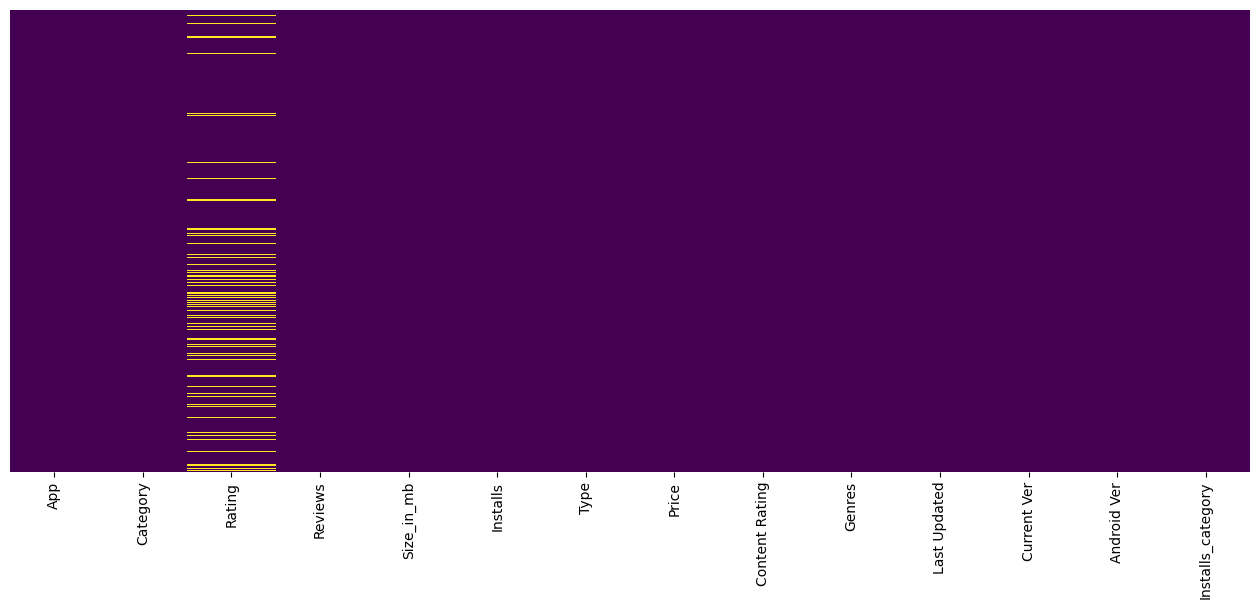

In [55]:
# make a figure size
plt.figure(figsize=(16, 6))
#plot the null values in each column
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis') # this will show the heatmap of null values in the dataframe

- There is another way, let's plot the missing values by percentage

Text(0.5, 1.0, 'Percentage of Missing Values in each Column')

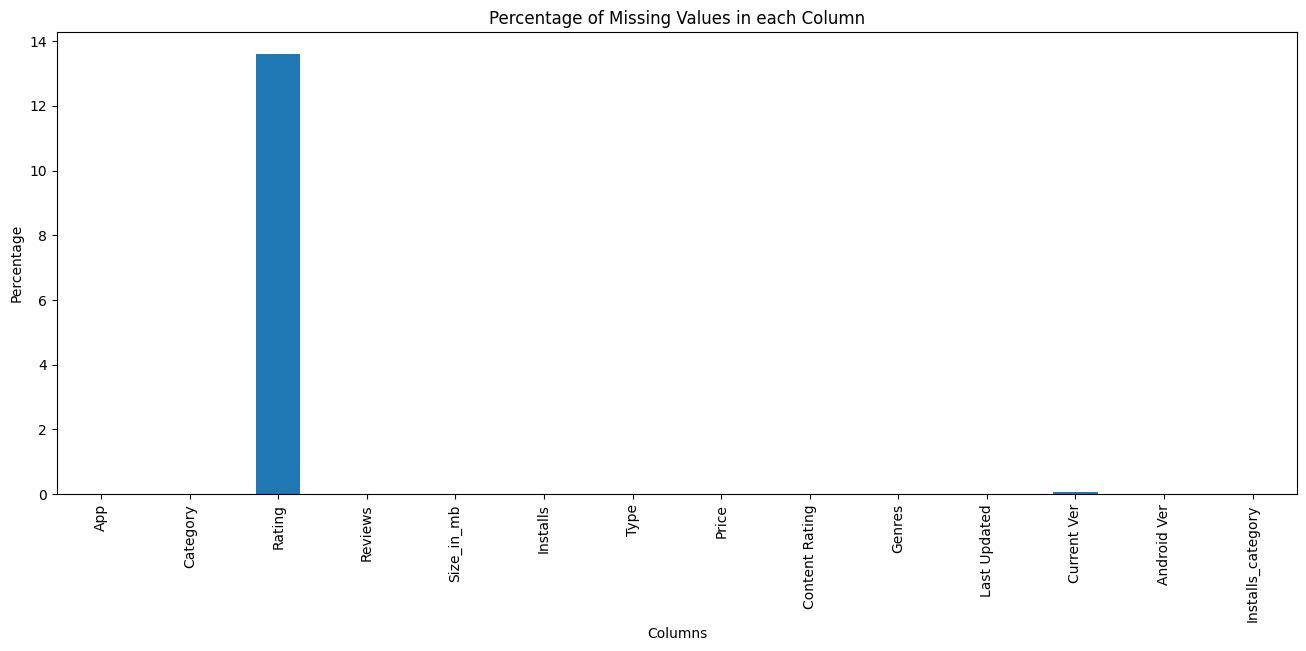

In [56]:
# make figure size
plt.figure(figsize=(16, 6))
# plot the null values by their percentage in each column
missing_percentage = df.isnull().sum()/len(df)*100
missing_percentage.plot(kind='bar')
# add the labels
plt.xlabel('Columns')
plt.ylabel('Percentage')
plt.title('Percentage of Missing Values in each Column')

- Let's plot the missing values other than 'Rating', 'Size_in_bytes' and 'Size_in_Mb' column
- We have missing percentage columns other than rating having less than one percent of missing values, we will plot them as follows:

Text(0.5, 1.0, 'Percentage of Missing Values in each Column without Rating column')

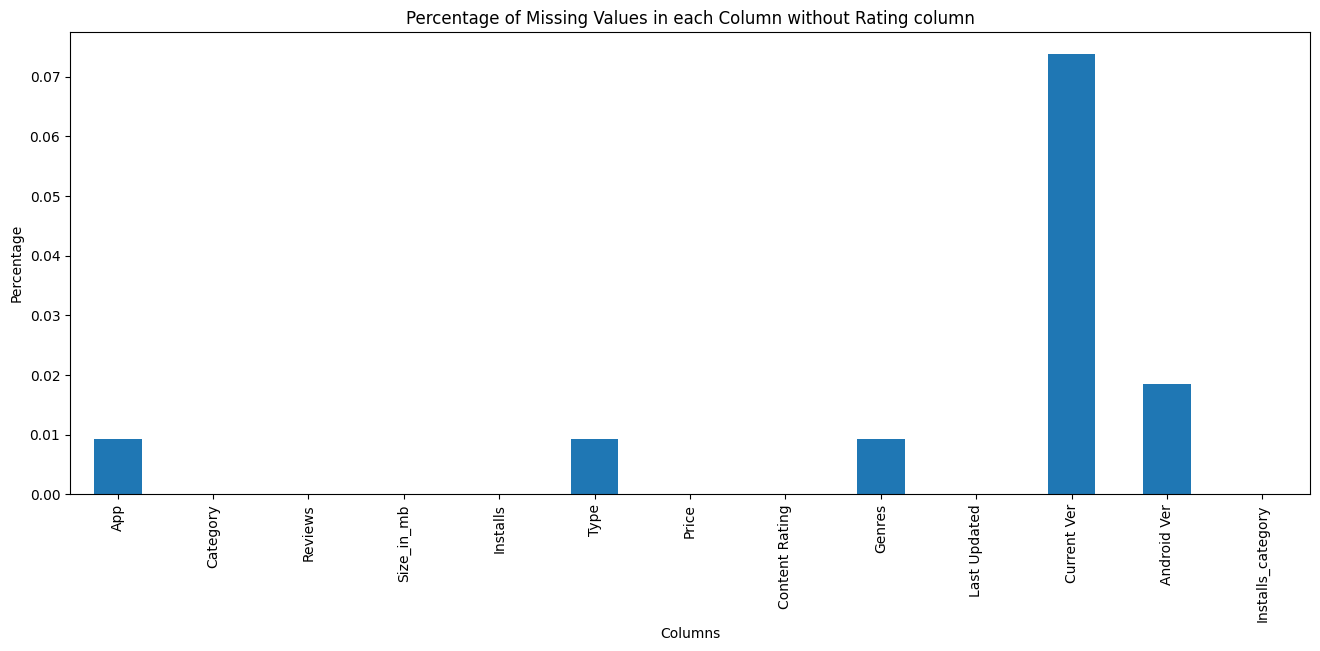

In [57]:
plt.figure(figsize=(16, 6)) # make figure size
missing_percentage[missing_percentage < 1].plot(kind='bar') # plot the null values by their percentage in each column
plt.xlabel('Columns') # add the x-axis labels
plt.ylabel('Percentage') # add the labels for y-axis
plt.title('Percentage of Missing Values in each Column without Rating column')  # add the title for the plot

In [58]:
df.isnull().sum().sort_values(ascending=False) # this will show the number of null values in each column in descending order

Rating               1474
Current Ver             8
Android Ver             2
Type                    1
Genres                  1
App                     1
Installs                0
Size_in_mb              0
Reviews                 0
Category                0
Content Rating          0
Price                   0
Last Updated            0
Installs_category       0
dtype: int64

In [59]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False) # this will show the percentage of null values in each column

Rating               13.596532
Current Ver           0.073794
Android Ver           0.018448
Type                  0.009224
Genres                0.009224
App                   0.009224
Installs              0.000000
Size_in_mb            0.000000
Reviews               0.000000
Category              0.000000
Content Rating        0.000000
Price                 0.000000
Last Updated          0.000000
Installs_category     0.000000
dtype: float64

## Observations:
---
- We have 1474 missing values in the `'Rating'` column, which is 13.6% of the total values in the column.
- We have 8 missing value in the `'Current Ver'` column, which is 0.07% of the total values in the column.
- We have 2 missing values in the `'Android Ver'` column, which is 0.01% of the total values in the column.
- We have only 1 missing value in `Category`, `Type` and `Genres` columns, which is 0.009% of the total values in the column.

---

In [60]:
df.describe() # these are numeric columns

,Size_in_mb,Installs,Price
count,10841.000000,1.084100e+04,10841.000000
mean,20.321034,1.546291e+07,1.027273
std,21.231352,8.502557e+07,15.948971
min,0.008301,0.000000e+00,0.000000
25%,5.600000,1.000000e+03,0.000000
50%,12.000000,1.000000e+05,0.000000
75%,27.000000,5.000000e+06,0.000000
max,100.000000,1.000000e+09,400.000000


---
## **Observations**
- Here we have a small quantity of missing values in few columns like 0.001% or else 

- Before going ahead, let's remove the rows with missing values in the `Current Ver`, `Android Ver`, `Category`, `Type` and `Genres` columns, as they are very less in number and will not affect our analysis.

In [61]:
# length before removing null values
print(f"Length of the dataframe before removing null values: {len(df)}")

Length of the dataframe before removing null values: 10841


In [62]:
# remove the rows having null values in the 'Current Ver', 'Android Ver', 'Category', 'Type' and 'Genres' column
df.dropna(subset=['Current Ver', 'Android Ver', 'Category', 'Type', 'Genres'], inplace=True)

In [63]:
# length after removing null values
print(f"Length of the dataframe after removing null values: {len(df)}")

Length of the dataframe after removing null values: 10829


- We have removed `12` rows having null values in the `Current Ver`, `Android Ver`, `Category`, `Type` and `Genres` columns.

In [64]:
# let's check the null values again
df.isnull().sum().sort_values(ascending=False)

Rating               1469
App                     0
Category                0
Reviews                 0
Size_in_mb              0
Installs                0
Type                    0
Price                   0
Content Rating          0
Genres                  0
Last Updated            0
Current Ver             0
Android Ver             0
Installs_category       0
dtype: int64

---
## **Observations**
- Only `Rating` column is left with missing values.
  - We know that we have to be carefull while deadling with `Rating` column, as it is directly linked with the `Installs` column.
---

In [65]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size_in_mb', 'Installs',
       'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated',
       'Current Ver', 'Android Ver', 'Installs_category'],
      dtype='object')

In [66]:
# use groupby function to find the trend of Rating in each Installs_category
df.groupby('Installs_category')['Rating'].describe()

,count,unique,top,freq
Installs_category,,,,
no,0,0,NaN,NaN
Very low,81.0,12.0,5.0,59.0
Low,1278.0,39.0,5.0,211.0
Moderate,1440.0,35.0,4.5,132.0
More than moderate,1616.0,32.0,4.2,167.0
High,2113.0,27.0,4.3,262.0
Very High,2004.0,22.0,4.4,309.0
Top Notch,828.0,15.0,4.4,186.0


- Replace the respective missing values of Rating, with respect to the average give in each 'Installs Category'!

In [67]:
# impute null values in Rating with the mean Rating of each Installs_category
df["Rating"] = df.groupby("Installs_category")["Rating"].transform(lambda x: x.fillna(x.mean()))

In [68]:
df['Rating'].isnull().sum()

np.int64(14)

- here we have still some misisng values like 14 
- now we apply fillna direct by mean

In [69]:

# fill remaining null values in rating
df['Rating'] = df['Rating'].fillna(df['Rating'].mean())

In [70]:
df['Rating'].isnull().sum()

np.int64(0)

In [71]:
# check nan values in the dataframe
df.isnull().sum()

App                  0
Category             0
Rating               0
Reviews              0
Size_in_mb           0
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          0
Android Ver          0
Installs_category    0
dtype: int64

- there is no null values in dataset

- But wait, we have to check for the duplicates as well, as they can affect our analysis.

In [72]:
# find duplicate if any
df.duplicated().sum()

np.int64(483)

This shows us total duplicates, but we can also check based on the app name, as we know that every app has a unique name.

In [73]:
# find duplicate if any in the 'App' column
df['App'].duplicated().sum()

np.int64(1181)

- Oops! we have 1181 dupicate app names
- Can we find a column which can help us to remove the duplicates?

let's check for number of duplicates in each column using a for loop and printing the output

In [74]:
# let's check for number of duplicates
for col in df.columns:
    print(f"Number of duplicates in {col} column are: {df[col].duplicated().sum()}")

Number of duplicates in App column are: 1181
Number of duplicates in Category column are: 10796
Number of duplicates in Rating column are: 10784
Number of duplicates in Reviews column are: 4830
Number of duplicates in Size_in_mb column are: 10367
Number of duplicates in Installs column are: 10809
Number of duplicates in Type column are: 10827
Number of duplicates in Price column are: 10737
Number of duplicates in Content Rating column are: 10823
Number of duplicates in Genres column are: 10710
Number of duplicates in Last Updated column are: 9453
Number of duplicates in Current Ver column are: 7998
Number of duplicates in Android Ver column are: 10796
Number of duplicates in Installs_category column are: 10821


This means that the only better way to find duplicates is to check for whole data

In [75]:
# print the number of duplicates in df
print(f"Number of duplicates in df are: {df.duplicated().sum()}")

Number of duplicates in df are: 483


- Find and watch all duplicates if they are real!

In [76]:
# find exact duplicates and print them
df[df['App'].duplicated(keep=False)].sort_values(by='App').head(8)

,App,Category,Rating,Reviews,Size_in_mb,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_category
1393,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3.8,500000,Free,0.00,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up,High
1407,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3.8,500000,Free,0.00,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up,High
2543,1800 Contacts - Lens Store,MEDICAL,4.7,23160,26.0,1000000,Free,0.00,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up,High
2322,1800 Contacts - Lens Store,MEDICAL,4.7,23160,26.0,1000000,Free,0.00,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up,High
2385,2017 EMRA Antibiotic Guide,MEDICAL,4.4,12,3.8,1000,Paid,16.99,Everyone,Medical,"January 27, 2017",1.0.5,4.0.3 and up,Low
2256,2017 EMRA Antibiotic Guide,MEDICAL,4.4,12,3.8,1000,Paid,16.99,Everyone,Medical,"January 27, 2017",1.0.5,4.0.3 and up,Low
1337,21-Day Meditation Experience,HEALTH_AND_FITNESS,4.4,11506,15.0,100000,Free,0.00,Everyone,Health & Fitness,"August 2, 2018",3.0.0,4.1 and up,More than moderate
1434,21-Day Meditation Experience,HEALTH_AND_FITNESS,4.4,11506,15.0,100000,Free,0.00,Everyone,Health & Fitness,"August 2, 2018",3.0.0,4.1 and up,More than moderate


- Remove Duplicates

In [77]:
# remove the duplicates
df.drop_duplicates(inplace=True)

In [78]:
# print the number of rows and columns after removing duplicates
print(f"Number of rows after removing duplicates: {df.shape[0]}")

Number of rows after removing duplicates: 10346


- Now we have removed 483 duplicates from the dataset. and have 10346 rows left.

---

## 5️⃣ Exploratory Analysis: Answering Key Questions

Now let's explore our clean data and uncover insights about the Google Play Store ecosystem.

### 📱 Question 1: Which categories have the most apps?

In [79]:
# which category has highest number of apps
df['Category'].value_counts().head(10) # this will show the top 10 categories with highest number of apps

Category
FAMILY             1939
GAME               1121
TOOLS               841
BUSINESS            427
MEDICAL             408
PRODUCTIVITY        407
PERSONALIZATION     386
LIFESTYLE           373
COMMUNICATION       366
FINANCE             360
Name: count, dtype: int64

### 📊 Question 2: Which categories drive the most installs?

In [80]:
# category with highest number of Installs
df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)

Category
GAME                  31544024415
COMMUNICATION         24152276251
SOCIAL                12513867902
PRODUCTIVITY          12463091369
TOOLS                 11452271905
FAMILY                10041632405
PHOTOGRAPHY            9721247655
TRAVEL_AND_LOCAL       6361887146
VIDEO_PLAYERS          6222002720
NEWS_AND_MAGAZINES     5393217760
Name: Installs, dtype: int64

### 💬 Question 3: Where do users leave the most reviews?

In [81]:
# Category with highest number of Reviews
df.groupby('Category')['Reviews'].sum().sort_values(ascending=False).head(10)

Category
PARENTING              8617941763614343114133936378967107559497632484...
SOCIAL                 7815830666577313860625949173295532622492170147...
MAPS_AND_NAVIGATION    7232629156815348110480050459432695644349284201...
EDUCATION              6289924181893254485375314299776977032346407510...
COMMUNICATION          5664284769119316125257964299514290354604324341...
ENTERTAINMENT          5456208116562894829677147008910939985095241225...
SPORTS                 5211381802283662828824597951338259119951733342...
FAMILY                 4706944214544499101477412753339832026757611161...
GAME                   4447388277222642242667725425814889736920352341...
HEALTH_AND_FITNESS     4281561577380983113927233722012540059220098117...
Name: Reviews, dtype: object

### ⭐ Question 4: Which categories have the highest user ratings?

In [82]:
# Category with highest average Rating
df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)

Category
EVENTS                 4.394346
EDUCATION              4.373794
ART_AND_DESIGN         4.364624
BOOKS_AND_REFERENCE    4.358435
PERSONALIZATION        4.332999
GAME                   4.281926
HEALTH_AND_FITNESS     4.273890
SOCIAL                 4.260061
PARENTING              4.259759
SHOPPING               4.253376
Name: Rating, dtype: float64

## 6️⃣ Summary & Key Insights

### 📈 Data Transformation Summary

✅ **Cleaned & Ready:** Started with 10,841 raw app records, cleaned to 10,346 valid records  
✅ **Zero Missing Values:** Intelligently handled missing data without losing insights  
✅ **Numeric Columns Fixed:** Converted Size, Installs, and Price to proper numeric types  
✅ **Duplicates Removed:** Eliminated 483 duplicate entries  
✅ **Features Engineered:** Created `Installs_category` for better segmentation analysis  

---

### 🙏 If You Found This Helpful...

This notebook demonstrates complete data wrangling and EDA workflow — from raw, messy data to clean insights. If you learned something useful here, please consider:

- **Upvoting** this notebook (it helps other learners find it!)
- **Commenting** with your own insights or improvements
- **Sharing** if you think others would benefit

Every upvote helps this content reach more data scientists and app developers. Thank you for reading! 🚀
